# Generate CD38-centered publication figures

**Biology rationale.** CD38 expression and related niche features support interpretation of plasma-cell targeting and immune-cell interactions.

**Aim.** Assemble publication-ready summaries of CD38 expression and associated cell-type comparisons.

**Data input.** `./250817-AL-all78umap-singletonly-umap.rds`, `TME.noverlabel.csv`, `PC.noverlabel.csv`, `Tcell.noverlabel.csv`, `Bcell.noverlabel.csv`



**Data outputs.** `CD38_nonPC_cell_level_table.csv`

## 1. Packages and setup


In [1]:
library(Seurat)
library(patchwork)
library(speckle)
library(limma)
library(ggplot2)
library(DoubletFinder)
library(SoupX)
library(DropletUtils)
library(Matrix)
library(celda)
library(SingleCellExperiment)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t






Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollaps

In [2]:
sce1<-readRDS(file='./250817-AL-all78umap-singletonly-umap.rds')

Assign the cell type annotation for each lineage to the bone marrow microenvironment cells.

In [3]:
library(tidyverse)

# --- Read ---
label1 <- readr::read_csv("TME.noverlabel.csv", show_col_types = FALSE)
label2 <- readr::read_csv("PC.noverlabel.csv", show_col_types = FALSE)
label3 <- readr::read_csv("Tcell.noverlabel.csv", show_col_types = FALSE)
label4 <- readr::read_csv("Bcell.noverlabel.csv", show_col_types = FALSE)
label5 <- readr::read_csv("Mono.noverlabel.csv", show_col_types = FALSE)
label6 <- readr::read_csv("NKcell.noverlabel.csv", show_col_types = FALSE)

# --- Helper: unify names & types ---
normalize <- function(df) {
  df %>%
    rename(
      barcode = any_of(c("barcode","Barcode")),  # handles the 'barocde' typo
      Nover   = any_of(c("Nover","Annotation","celltype","final_label","clonotype"))
    ) %>%
    mutate(
      barcode = as.character(barcode),
      # make Nover numeric; non-numeric becomes NA (prevents bind_rows() type clash)
      Nover   = as.character(Nover)
    ) %>%
    select( barcode, Nover)
}

label1 <- normalize(label1)
label2 <- normalize(label2)
label3 <- normalize(label3)
label4 <- normalize(label4)
label5 <- normalize(label5)
label6 <- normalize(label6)

# --- Build replacement lookups from label3–6 ---
lookup <- bind_rows(
  mutate(label2, .src = "Plasmacell"),
  mutate(label3, .src = "Tcell"),
  mutate(label4, .src = "Bcell"),
  mutate(label5, .src = "Mono"),
  mutate(label6, .src = "NKcell")
) %>%
  # priority order
  arrange(factor(.src, levels = c( "Plasmacell","Tcell","Bcell","Mono","NKcell"))) %>%
  group_by(barcode) %>%
  summarise(Nover_new = first(na.omit(Nover)), .groups = "drop")

# --- Replace Nover in label1 using the lookup (by barcode) ---
label1_updated <- label1 %>%
  left_join(lookup, by = "barcode") %>%
  mutate(Nover = coalesce(Nover_new, Nover)) %>%
  select(barcode, Nover)

# --- Bind label2 on it ---
final_tbl <- unique(bind_rows(label1_updated, label2))

# (optional) save
# write_csv(final_tbl, "combined_noverlabel.csv")

final_tbl


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ lubridate 1.9.4     ✔ tibble    3.3.1
✔ purrr     1.1.0     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ lubridate::%within%()    masks IRanges::%within%()
✖ dplyr::collapse()        masks IRanges::collapse()
✖ dplyr::combine()         masks Biobase::combine(), BiocGenerics::combine()
✖ dplyr::count()           masks matrixStats::count()
✖ dplyr::desc()            masks IRanges::desc()
✖ tidyr::expand()          masks Matrix::expand(), S4Vectors::expand()
✖ dplyr::filter()          masks stats::filter()
✖ dplyr::first()           masks S4Vectors::first()
✖ dplyr::lag()             masks stats::lag()
✖ tidyr::pack()            masks Matrix::pack()
✖ BiocGenerics::Position() masks ggplot2::Position(), base::Position()
✖ purrr::reduce()          masks GenomicRanges::reduce(

barcode,Nover
<chr>,<chr>
ALl14_AAACCCAGTTAAACCC-1,CD4_CM
ALl14_AAACCCATCGTCCTTG-1,Erythroid_CD34- CD71+ GlyA+
ALl14_AAACCCATCTCATTAC-1,CD14 Mono_set1High_set2High
ALl14_AAACCCATCTGTAACG-1,CD4_CM
ALl14_AAACGAAAGACCCTTA-1,CD14 Mono_set1High_set2High
ALl14_AAACGAAAGTAACCGG-1,Granulocytes (Neutrophils)
ALl14_AAACGAAAGTGATAGT-1,CD4_EM
ALl14_AAACGAACAGAAATCA-1,Colony Forming Unit-Monocytes
ALl14_AAACGAACATAGAGGC-1,CD14 Mono_set1Low_set2High


In [4]:
rownames(final_tbl)<-final_tbl$barcode
sce1@meta.data<-cbind(sce1@meta.data,final_tbl[rownames(sce1@meta.data),])

Warning message:
“Setting row names on a tibble is deprecated.”


scCustomize v2.1.2
If you find the scCustomize useful please cite.
See 'samuel-marsh.github.io/scCustomize/articles/FAQ.html' for citation info.

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


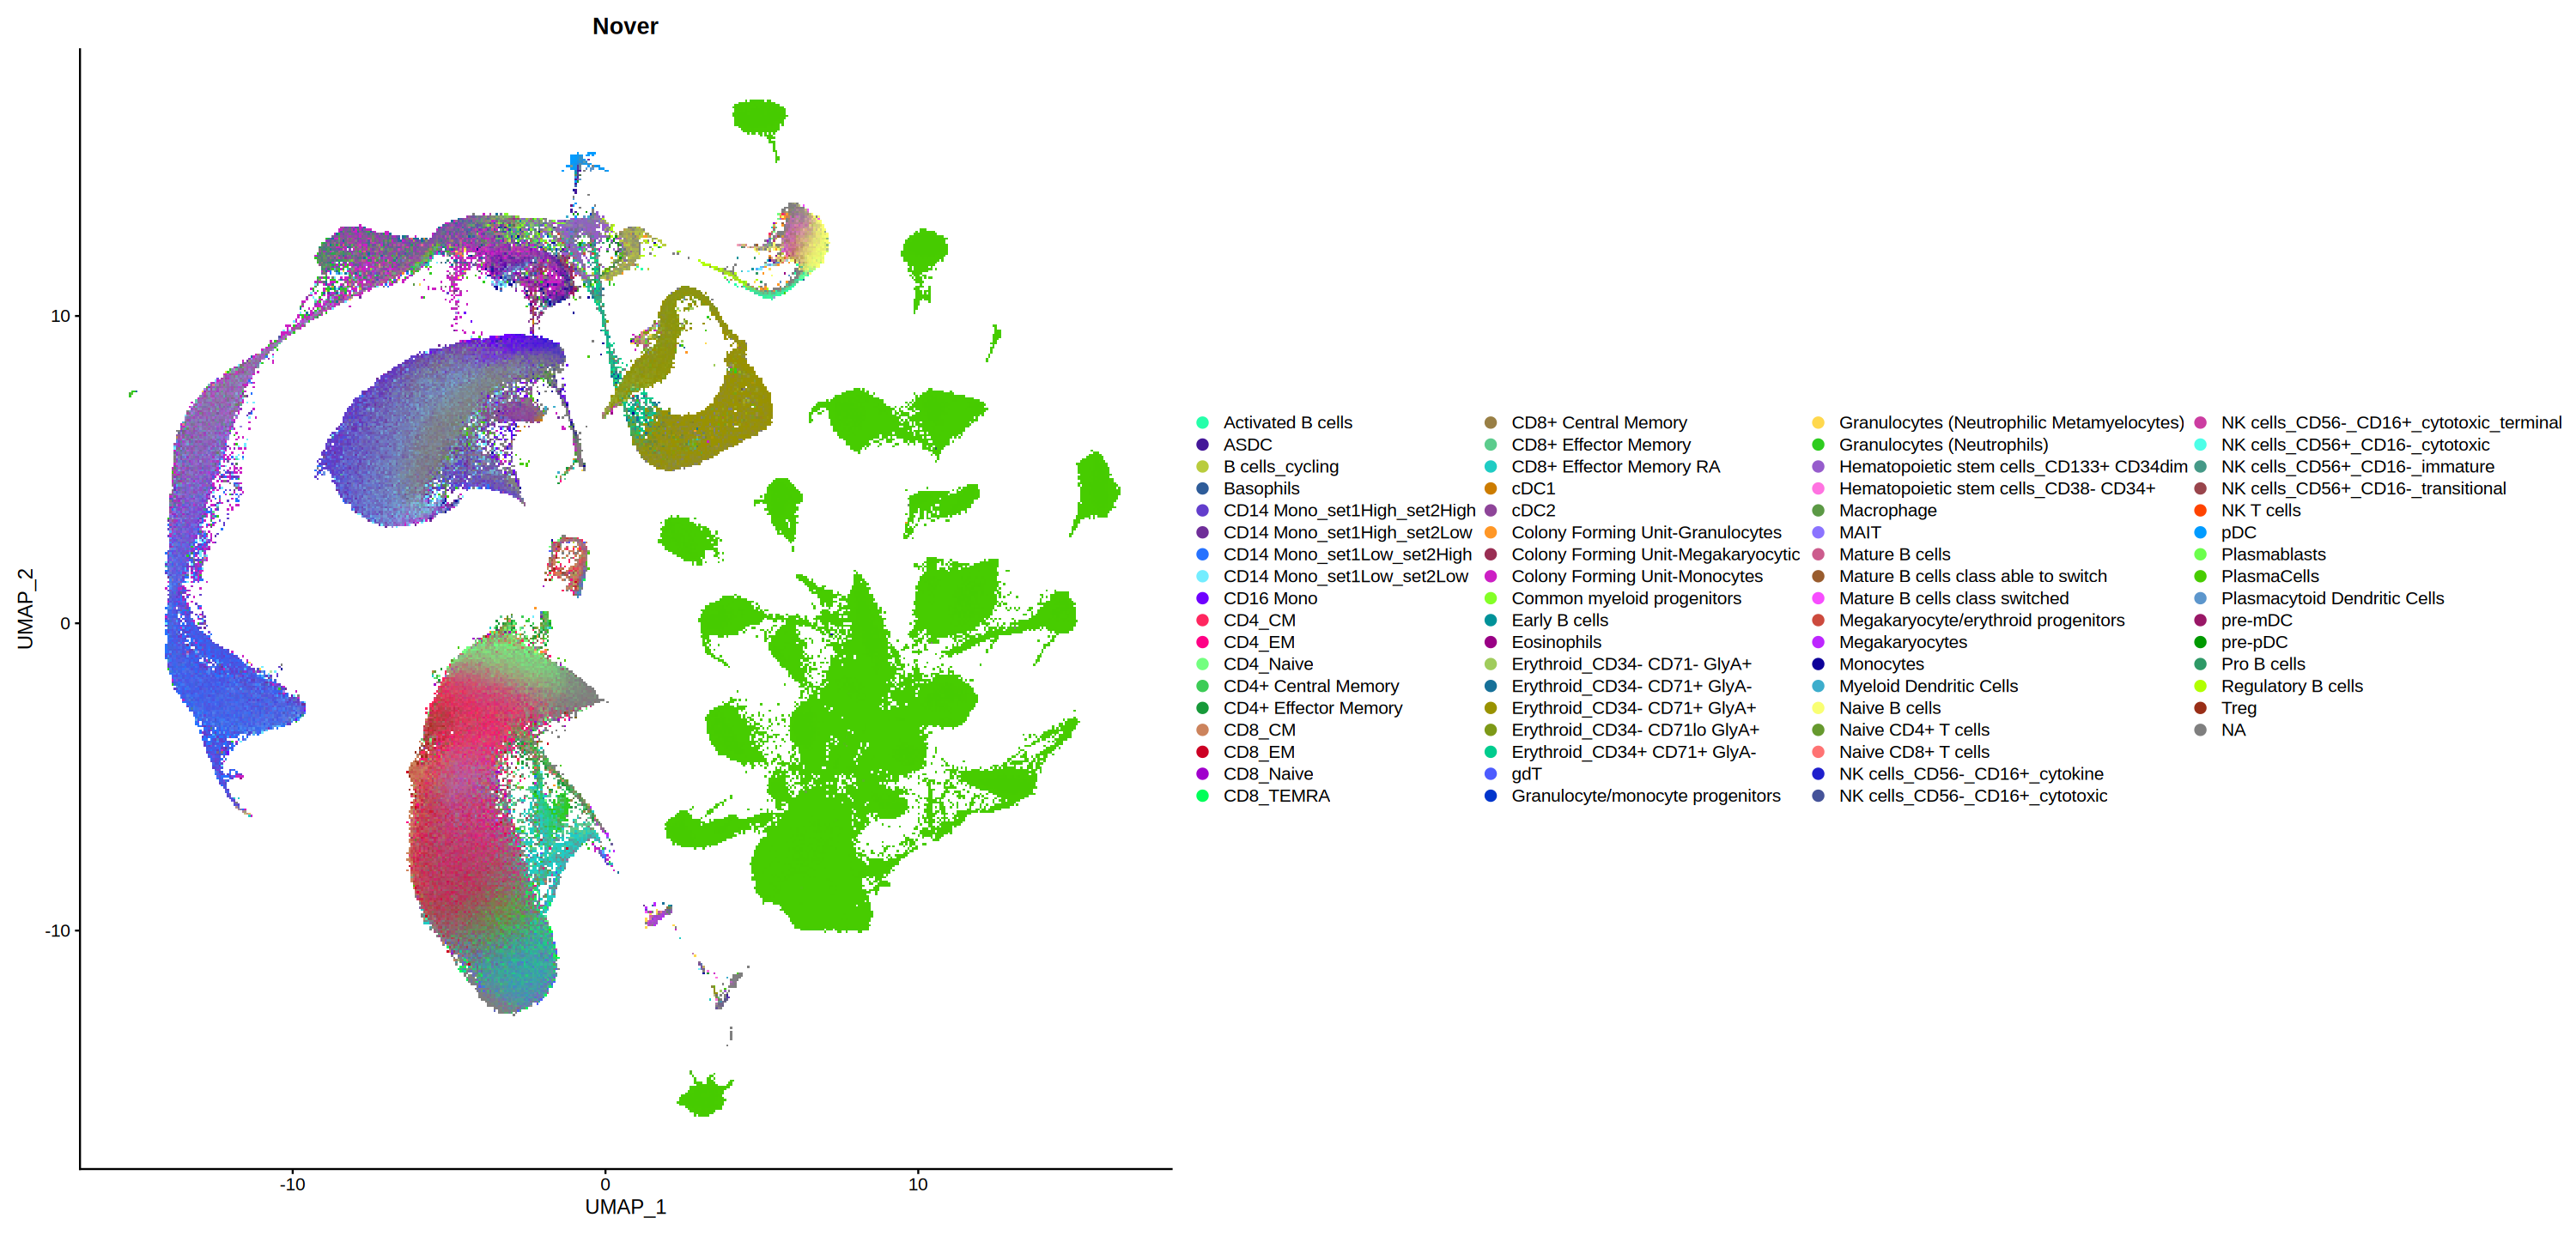

In [5]:
library(scCustomize)
options(repr.plot.height=12,repr.plot.width=25)
DimPlot_scCustom(sce1, pt.size=1,reduction = "UMAP", group.by = c("Nover"),label=F) 

## 2. Visualization and figure generation


In [6]:
sce1

An object of class Seurat 
36601 features across 630111 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, UMAP

In [7]:
# First: optional example filter you had for 'plasma' in orig.ident
cells_to_keep <- rownames(sce1@meta.data)[!grepl("plasma", sce1@meta.data$orig.ident)]
sce1 <- subset(sce1, cells = cells_to_keep)

# Keywords to exclude (substring match, case-insensitive) EXCEPT "Mature B cells" which is exact only
keywords_sub <- c("Central","Effector","Mature NK cells_CD56-",
                  "Mature NK cells_CD56+","Monocytes",
                  "Naive CD8+ T cells","Naive CD4+ T cells")

# Build regex for substring keywords (escape specials)
rx_sub <- paste(paste0("\\Q", keywords_sub, "\\E"), collapse = "|")

# Column to check
v <- as.character(sce1@meta.data$Nover)

# 1) Exact match mask for just "Mature B cells"
m_exact_matureB <- tolower(trimws(v)) == "mature b cells"

# 2) Substring mask for the other keywords
m_sub <- grepl(rx_sub, v, ignore.case = TRUE, perl = TRUE)
m_sub[is.na(m_sub)] <- FALSE

# Combine: drop exact "Mature B cells" OR any substring match from keywords_sub
m_drop <- (m_exact_matureB %in% TRUE) | m_sub

cells_to_keep <- rownames(sce1@meta.data)[!m_drop]
sce1 <- subset(sce1, cells = cells_to_keep)


In [8]:
library(ggplot2)

extract_dimplot_colors <- function(p, group_col = "ident") {
  get_scale_vals <- function(p, aes_name) {
    sc <- p$scales$get_scales(aes_name)
    if (!is.null(sc)) {
      vals <- tryCatch(sc$range$range, error = function(e) NULL)
      lims <- tryCatch(sc$get_limits(), error = function(e) NULL)
      if (!is.null(vals) && length(vals) > 0) {
        if (is.null(lims) || length(lims) == 0) {
          if (!is.null(p$data[[group_col]])) {
            lims <- levels(factor(p$data[[group_col]]))
          } else {
            lims <- seq_along(vals)
          }
        }
        n <- min(length(vals), length(lims))
        return(setNames(vals[seq_len(n)], lims[seq_len(n)]))
      }
    }
    NULL
  }

  cols <- get_scale_vals(p, "colour")
  if (is.null(cols)) cols <- get_scale_vals(p, "color")
  if (is.null(cols)) cols <- get_scale_vals(p, "fill")

  if (is.null(cols)) {
    pb <- ggplot_build(p)
    if (length(pb$data) == 0) stop("Plot has no layer data; cannot extract colors.")
    d_layer <- pb$data[[1]]

    if (is.null(p$data[[group_col]])) {
      for (cand in c("ident", "group", "Nover", "Annotation")) {
        if (!is.null(p$data[[cand]])) { group_col <- cand; break }
      }
    }
    if (is.null(p$data[[group_col]])) {
      stop("Could not find a grouping column on the plot data.")
    }

    df_map <- data.frame(
      group = as.character(p$data[[group_col]]),
      colour = d_layer$colour,
      stringsAsFactors = FALSE
    )
    df_map <- df_map[!duplicated(df_map$group), ]
    cols <- setNames(df_map$colour, df_map$group)
  }

  cols
}

make_celltype_palette_from_umap <- function(obj, celltype_col, reduction_use = "UMAP", pt.size = 0.4) {
  p_umap_palette <- DimPlot_scCustom(
    obj,
    pt.size = pt.size,
    reduction = reduction_use,
    group.by = celltype_col,
    label = FALSE
  )
  pal <- extract_dimplot_colors(p_umap_palette, group_col = "ident")
  pal <- pal[!is.na(names(pal))]
  pal
}

theme_pub <- function(base_size = 11) {
  theme_classic(base_size = base_size) +
    theme(
      plot.title = element_text(face = "bold", hjust = 0, size = base_size + 1),
      axis.title = element_text(face = "bold"),
      axis.text = element_text(color = "black"),
      strip.background = element_rect(fill = "grey95", color = "grey70", linewidth = 0.3),
      strip.text = element_text(face = "bold", color = "black"),
      legend.title = element_text(face = "bold"),
      legend.key.size = grid::unit(0.35, "cm")
    )
}

fc_direction_cols <- c(
  "Post higher" = "#D73027",  # right / positive / red
  "Post lower"  = "#4575B4"   # left / negative / blue
)




## 3. Required for gene "tags" with text inside


As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.
Names of identity class contain underscores ('_'), replacing with dashes ('-')
This message is displayed once every 8 hours.


# A tibble: 6 × 2
  gene   n_available
  <chr>        <int>
1 CD38            58
2 KLRK1           58
3 LILRB1          58
4 PTGER2          58
5 PTGER4          58
6 PTGS2           58
# A tibble: 6 × 2
  gene   n_selected
  <chr>       <int>
1 CD38           10
2 KLRK1          10
3 LILRB1         10
4 PTGER2         10
5 PTGER4         10
6 PTGS2          10
# A tibble: 6 × 2
  gene   columns_in_heatmap
  <fct>               <int>
1 PTGS2                  10
2 KLRK1                  10
3 CD38                   10
4 LILRB1                 10
5 PTGER2                 10
6 PTGER4                 10


pdf 
  2

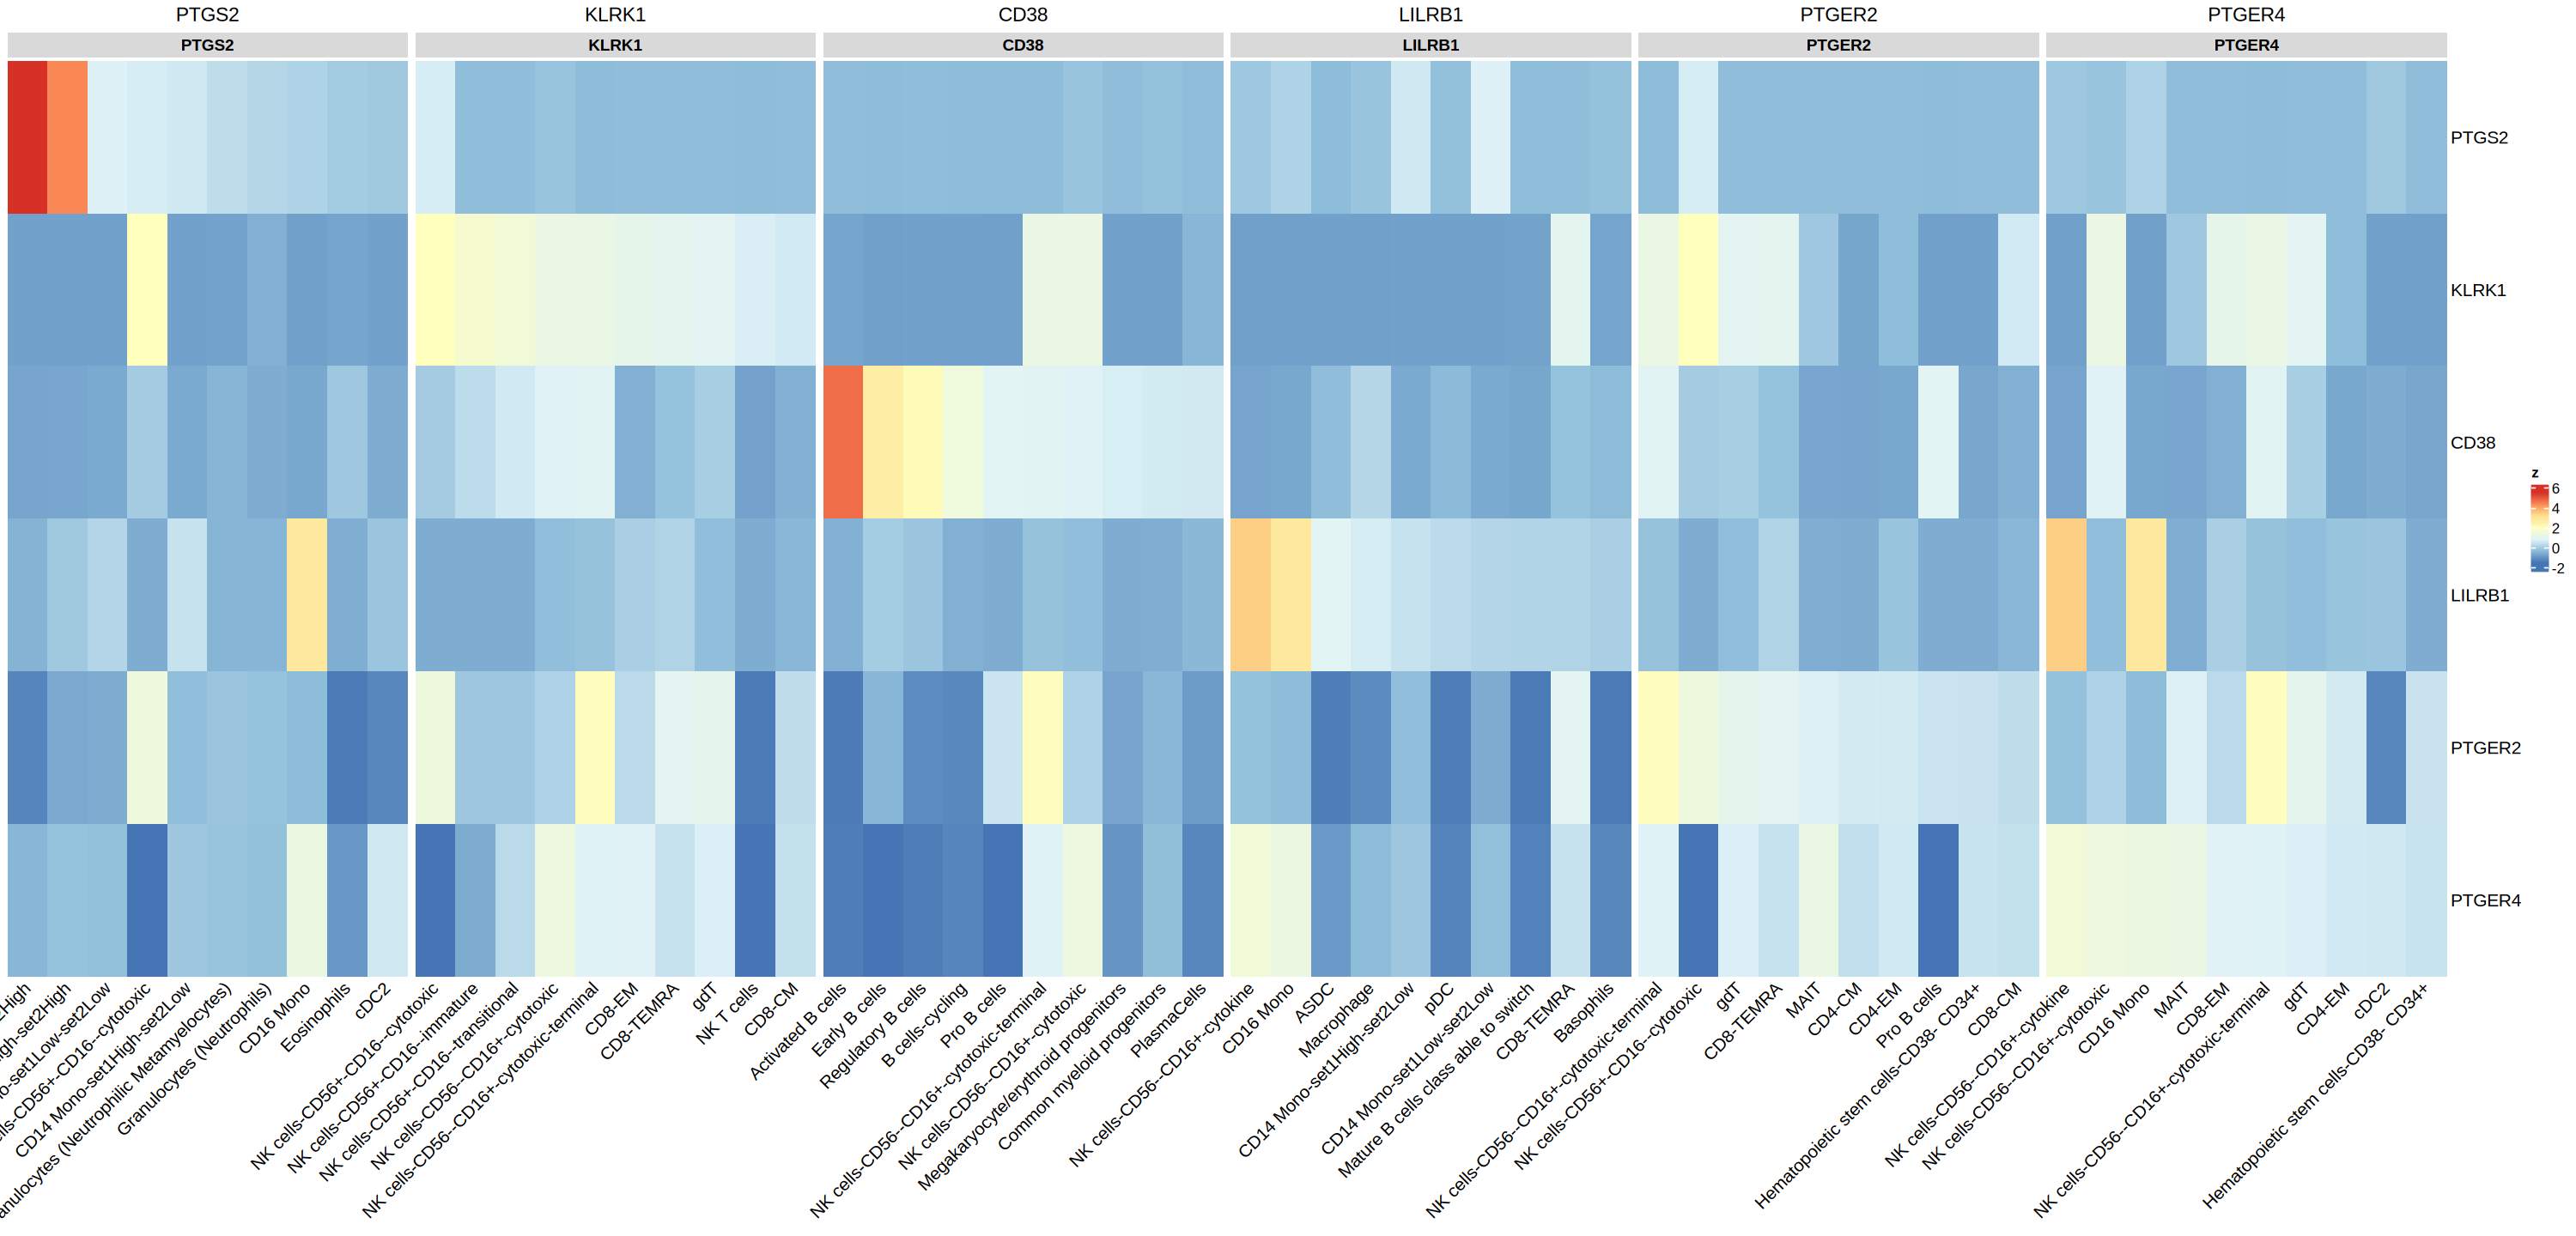

In [9]:
suppressPackageStartupMessages({
  library(Seurat)
  library(dplyr)
  library(tibble)
  library(tidyr)
})

# ---- required for gene "tags" with text inside ----
suppressPackageStartupMessages({
  library(ComplexHeatmap)
  library(circlize)
  library(grid)
  library(RColorBrewer)
})

# ---------------------------
# 0) Inputs
# ---------------------------
genes_use <- c("CD38","KLRK1","LILRB1","PTGS2","PTGER2","PTGER4")
group_col <- "Nover"
top_n <- 10

assay_use <- DefaultAssay(sce1)
slot_use  <- "data"   # normalized log; change to "counts" if needed

# ---------------------------
# 1) Average expression: genes x cell types
# ---------------------------
avg_list <- AverageExpression(
  sce1,
  assays   = assay_use,
  features = genes_use,
  group.by = group_col,
  slot     = slot_use,
  verbose  = FALSE
)

avg_mat <- avg_list[[assay_use]]
avg_mat <- avg_mat[intersect(rownames(avg_mat), genes_use), , drop = FALSE]

# ---------------------------
# 2) Long table + exactly top 10 per gene
# ---------------------------

# Remove potentially stale downstream objects
rm(
  list = intersect(
    c(
      "expr_all", "expr_long", "gene_order",
      "col_map", "col_order", "hm_full",
      "hm_full_z", "col_split", "top_anno", "ht"
    ),
    ls(envir = .GlobalEnv)
  ),
  envir = .GlobalEnv
)

TOP_N_REQUESTED <- 10L

expr_all <- as.data.frame(avg_mat, check.names = FALSE) %>%
  tibble::rownames_to_column("gene") %>%
  tidyr::pivot_longer(
    cols = -gene,
    names_to = "cell_type",
    values_to = "mean_expr"
  ) %>%
  dplyr::mutate(
    gene = as.character(gene),
    cell_type = as.character(cell_type),
    mean_expr = as.numeric(mean_expr)
  )

# Confirm that each gene has all 58 cell types before selection
available_counts <- expr_all %>%
  dplyr::count(gene, name = "n_available")

print(available_counts)

if (any(available_counts$n_available < TOP_N_REQUESTED)) {
  stop(
    "At least one gene has fewer than ",
    TOP_N_REQUESTED,
    " available cell types."
  )
}

# Select exactly 10 rows from each gene
expr_long <- expr_all %>%
  dplyr::group_by(gene) %>%
  dplyr::arrange(
    dplyr::desc(mean_expr),
    cell_type,
    .by_group = TRUE
  ) %>%
  dplyr::slice_head(n = 10L) %>%
  dplyr::mutate(
    rank_in_gene = dplyr::row_number()
  ) %>%
  dplyr::ungroup()

# Mandatory validation
selected_counts <- expr_long %>%
  dplyr::count(gene, name = "n_selected")

print(selected_counts)

if (!all(selected_counts$n_selected == 10L)) {
  stop(
    "Top-10 selection failed. Obtained counts: ",
    paste(
      selected_counts$gene,
      selected_counts$n_selected,
      sep = "=",
      collapse = ", "
    )
  )
}

# ---------------------------
# 3) Waterfall ordering
# ---------------------------
gene_order <- expr_long %>%
  dplyr::group_by(gene) %>%
  dplyr::summarise(
    top_expr = max(mean_expr, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  dplyr::arrange(
    dplyr::desc(top_expr),
    gene
  ) %>%
  dplyr::pull(gene)

expr_long <- expr_long %>%
  dplyr::mutate(
    gene = factor(gene, levels = gene_order)
  ) %>%
  dplyr::arrange(
    gene,
    rank_in_gene
  ) %>%
  dplyr::group_by(gene) %>%
  dplyr::mutate(
    block_pos = dplyr::row_number()
  ) %>%
  dplyr::ungroup() %>%
  dplyr::mutate(
    col_id = paste0(
      cell_type,
      "__",
      as.character(gene),
      "__rank",
      rank_in_gene
    )
  )

col_map <- expr_long %>%
  dplyr::select(
    col_id,
    cell_type,
    gene,
    mean_expr,
    rank_in_gene,
    block_pos
  )

col_order <- col_map$col_id

# Final checks
print(
  col_map %>%
    dplyr::count(gene, name = "columns_in_heatmap")
)

stopifnot(
  nrow(col_map) == length(genes_use) * 10L,
  ncol(avg_mat) == 58L
)

# ---------------------------
# 4) Build matrix showing ALL genes' expression for displayed columns
# ---------------------------
hm_full <- matrix(NA_real_,
                  nrow = nrow(avg_mat),
                  ncol = nrow(col_map),
                  dimnames = list(rownames(avg_mat), col_map$col_id))

for (j in seq_len(nrow(col_map))) {
  ct <- col_map$cell_type[j]
  hm_full[, j] <- avg_mat[, ct]
}

# Row-scale across displayed columns
scale_rows_full <- function(m) {
  z <- t(scale(t(m)))
  z[is.nan(z)] <- 0
  z
}
hm_full_z <- scale_rows_full(hm_full)

# Order rows/cols
hm_full_z <- hm_full_z[gene_order, col_order, drop = FALSE]

# ---------------------------
# 5) Gene "tags" (grey blocks with gene name inside) + plot
# ---------------------------
# column split factor defines the blocks
col_split <- factor(as.character(col_map$gene), levels = gene_order)

# top annotation: grey tag per block with the gene name centered
top_anno <- HeatmapAnnotation(
  Gene = anno_block(
    gp = gpar(fill = "grey85", col = NA),
    labels = levels(col_split),
    labels_gp = gpar(col = "black", fontsize = 10, fontface = "bold")
  ),
  show_annotation_name = FALSE
)

# heatmap color function (pheatmap-like diverging palette)
pal <- colorRampPalette(rev(brewer.pal(7, "RdYlBu")))(101)
rng <- range(hm_full_z, finite = TRUE)
col_fun <- circlize::colorRamp2(
  seq(rng[1], rng[2], length.out = length(pal)),
  pal
)

ht <- Heatmap(
  hm_full_z,
  name = "z",
  col = col_fun,
  cluster_rows = FALSE,
  cluster_columns = FALSE,

  # waterfall layout
  column_split = col_split,
  column_gap = unit(2, "mm"),

  # labels
  show_row_names = TRUE,
  row_names_side = "left",
  show_column_names = TRUE,
  column_labels = col_map$cell_type,   # repeats allowed
  column_names_rot = 45,

  # gene tags
  top_annotation = top_anno
)

# Jupyter sizing hint (ComplexHeatmap uses grid; sizing is controlled by device)
draw(ht, heatmap_legend_side = "right", annotation_legend_side = "right")

# ---------------------------
# 6) Save
# ---------------------------
write.csv(col_map, "Top_celltypes_per_gene_NO_dedup.csv", row.names = FALSE)

pdf("Heatmap_waterfall_NO_dedup_FULL_geneTagsGrey.pdf", width = 18, height = 5)
draw(ht, heatmap_legend_side = "right", annotation_legend_side = "right")
dev.off()


# ---- requires these packages ----
suppressPackageStartupMessages({
  library(ComplexHeatmap)
  library(circlize)
  library(grid)
  library(RColorBrewer)
})

# column blocks = gene that generated this block (from col_map)
col_split <- factor(as.character(col_map$gene), levels = gene_order)

# Grey "tag" with gene name INSIDE (one label per block)
top_anno <- HeatmapAnnotation(
  GeneTag = anno_block(
    gp = gpar(fill = "grey85", col = NA),                 # grey tag background
    labels = levels(col_split),                           # gene names (once per block)
    labels_gp = gpar(col = "black", fontsize = 11, fontface = "bold")
  ),
  show_annotation_name = FALSE,
  annotation_height = unit(6, "mm")                      # tag thickness (adjust)
)

# Heatmap color mapping
pal <- colorRampPalette(rev(brewer.pal(7, "RdYlBu")))(101)
rng <- range(hm_full_z, finite = TRUE)
col_fun <- circlize::colorRamp2(
  seq(rng[1], rng[2], length.out = length(pal)),
  pal
)

ht <- Heatmap(
  hm_full_z,
  name = "z",
  col = col_fun,
  cluster_rows = FALSE,
  cluster_columns = FALSE,

  # Waterfall blocks + spacing
  column_split = col_split,
  column_gap = unit(2, "mm"),

  # Put the gene-name "tags" on top
  top_annotation = top_anno,

  # Labels
  show_row_names = TRUE,
  show_column_names = TRUE,
  column_labels = col_map$cell_type,   # keep cell type labels (repeats allowed)
  column_names_rot = 45
)

draw(ht, heatmap_legend_side = "right")



# A tibble: 6 × 2
  gene   n_selected
  <chr>       <int>
1 CD38           10
2 KLRK1          10
3 LILRB1         10
4 PTGER2         10
5 PTGER4         10
6 PTGS2          10


Top 10 from 6 genes produced 37 unique cell types.



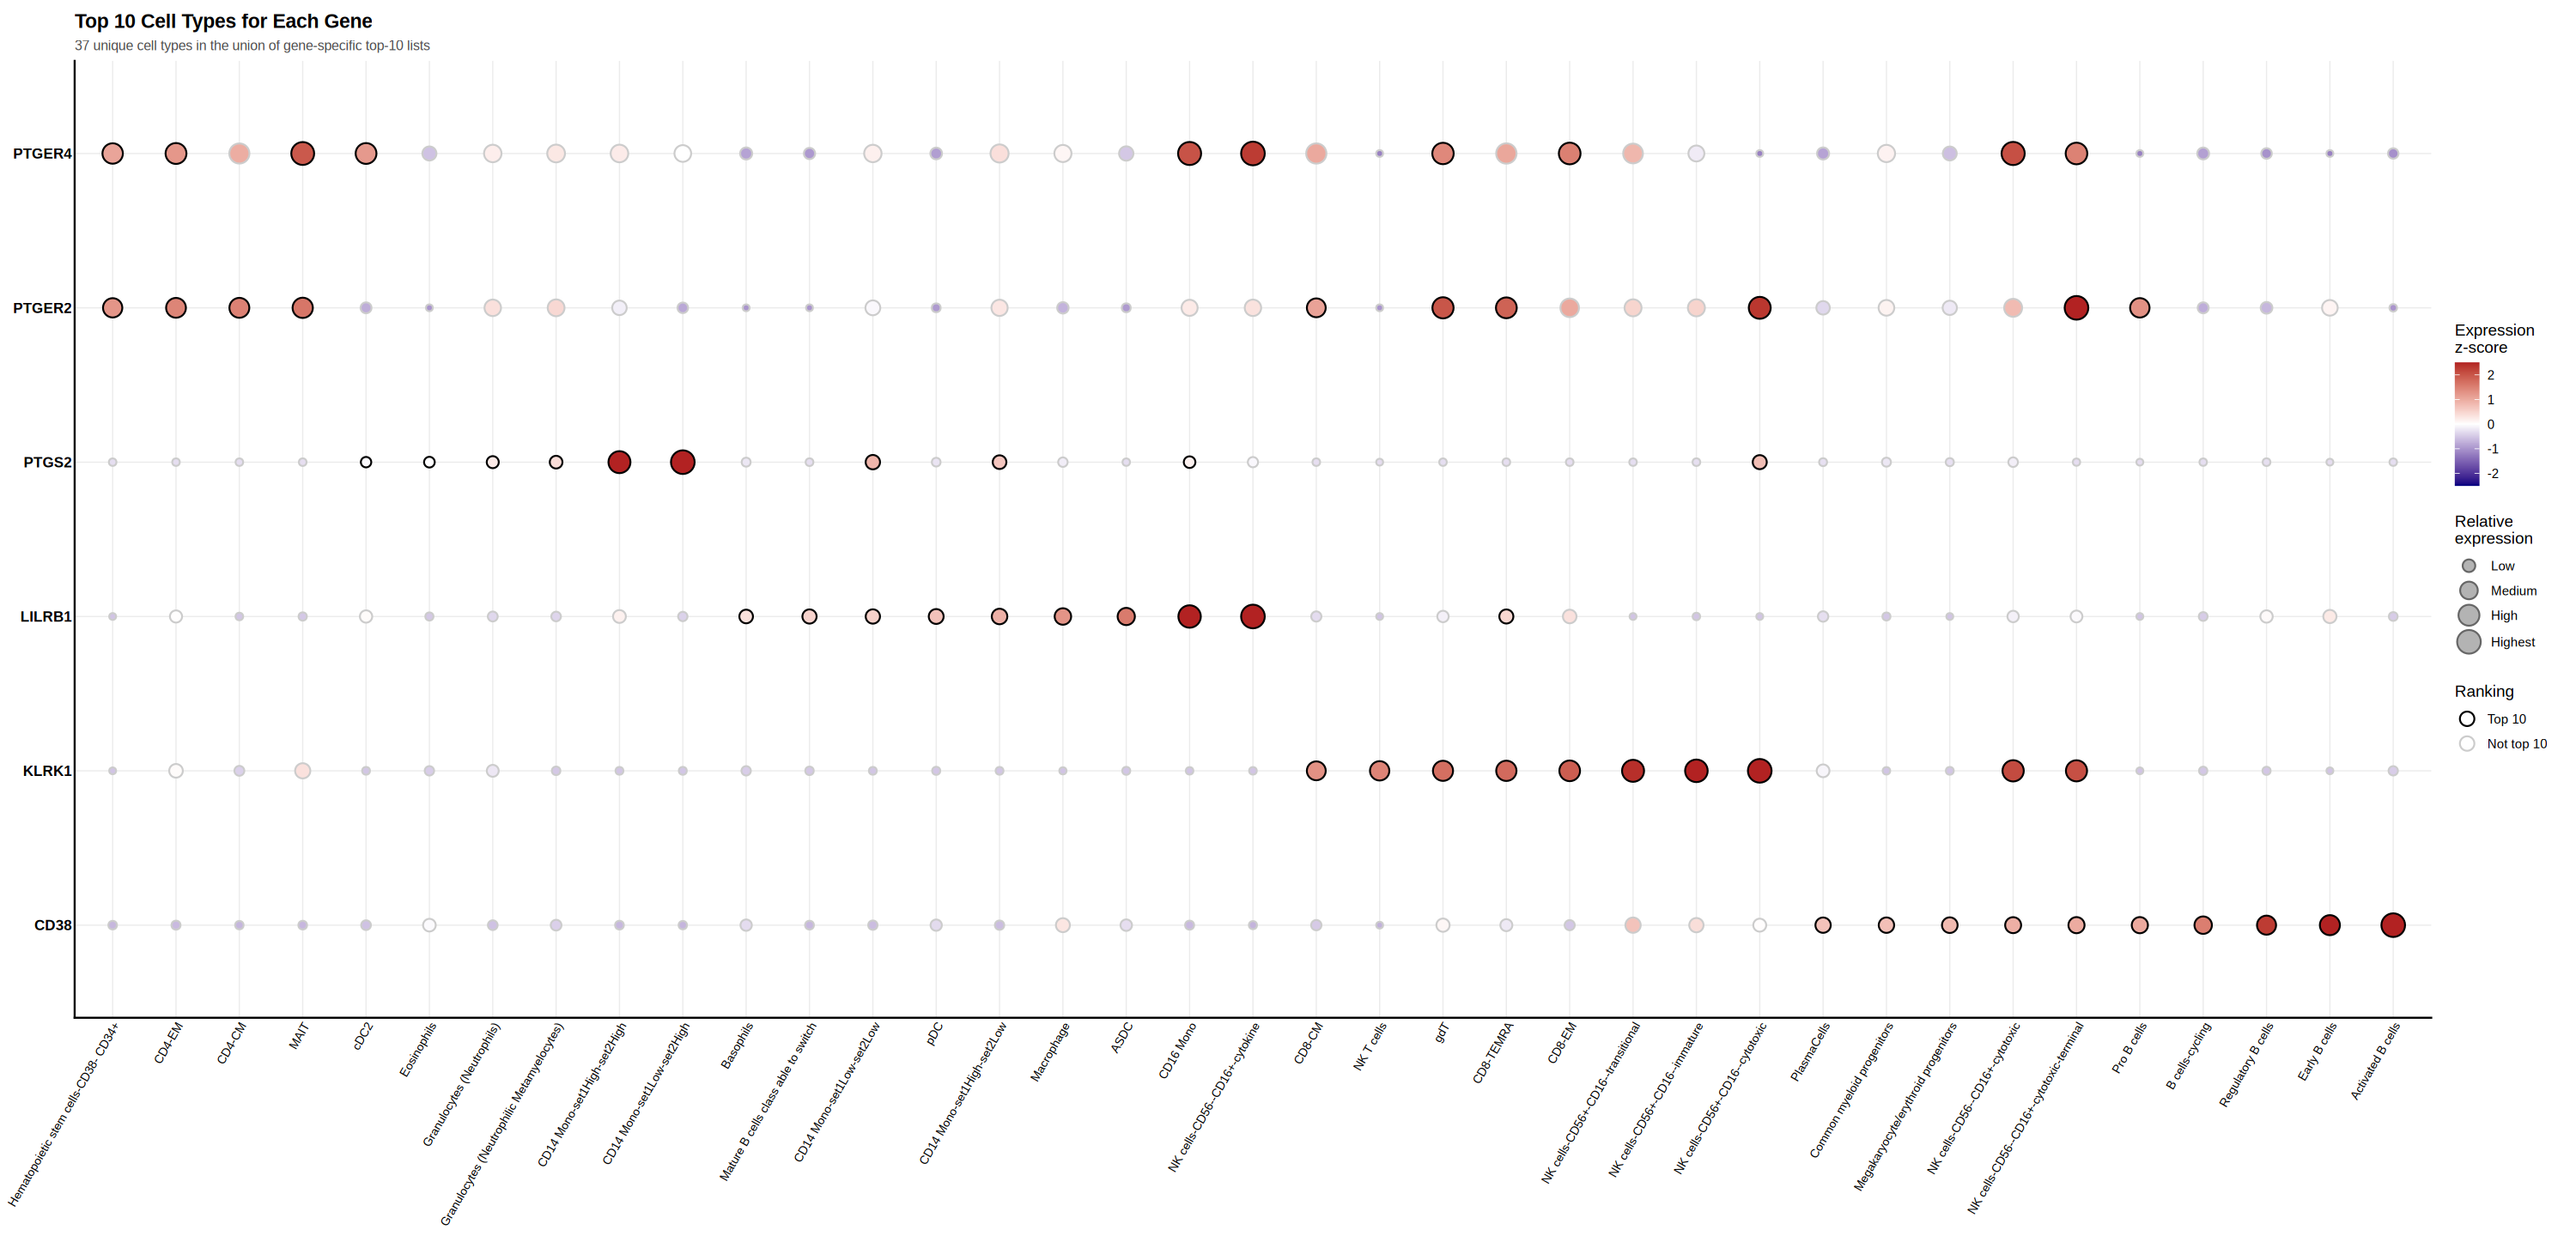

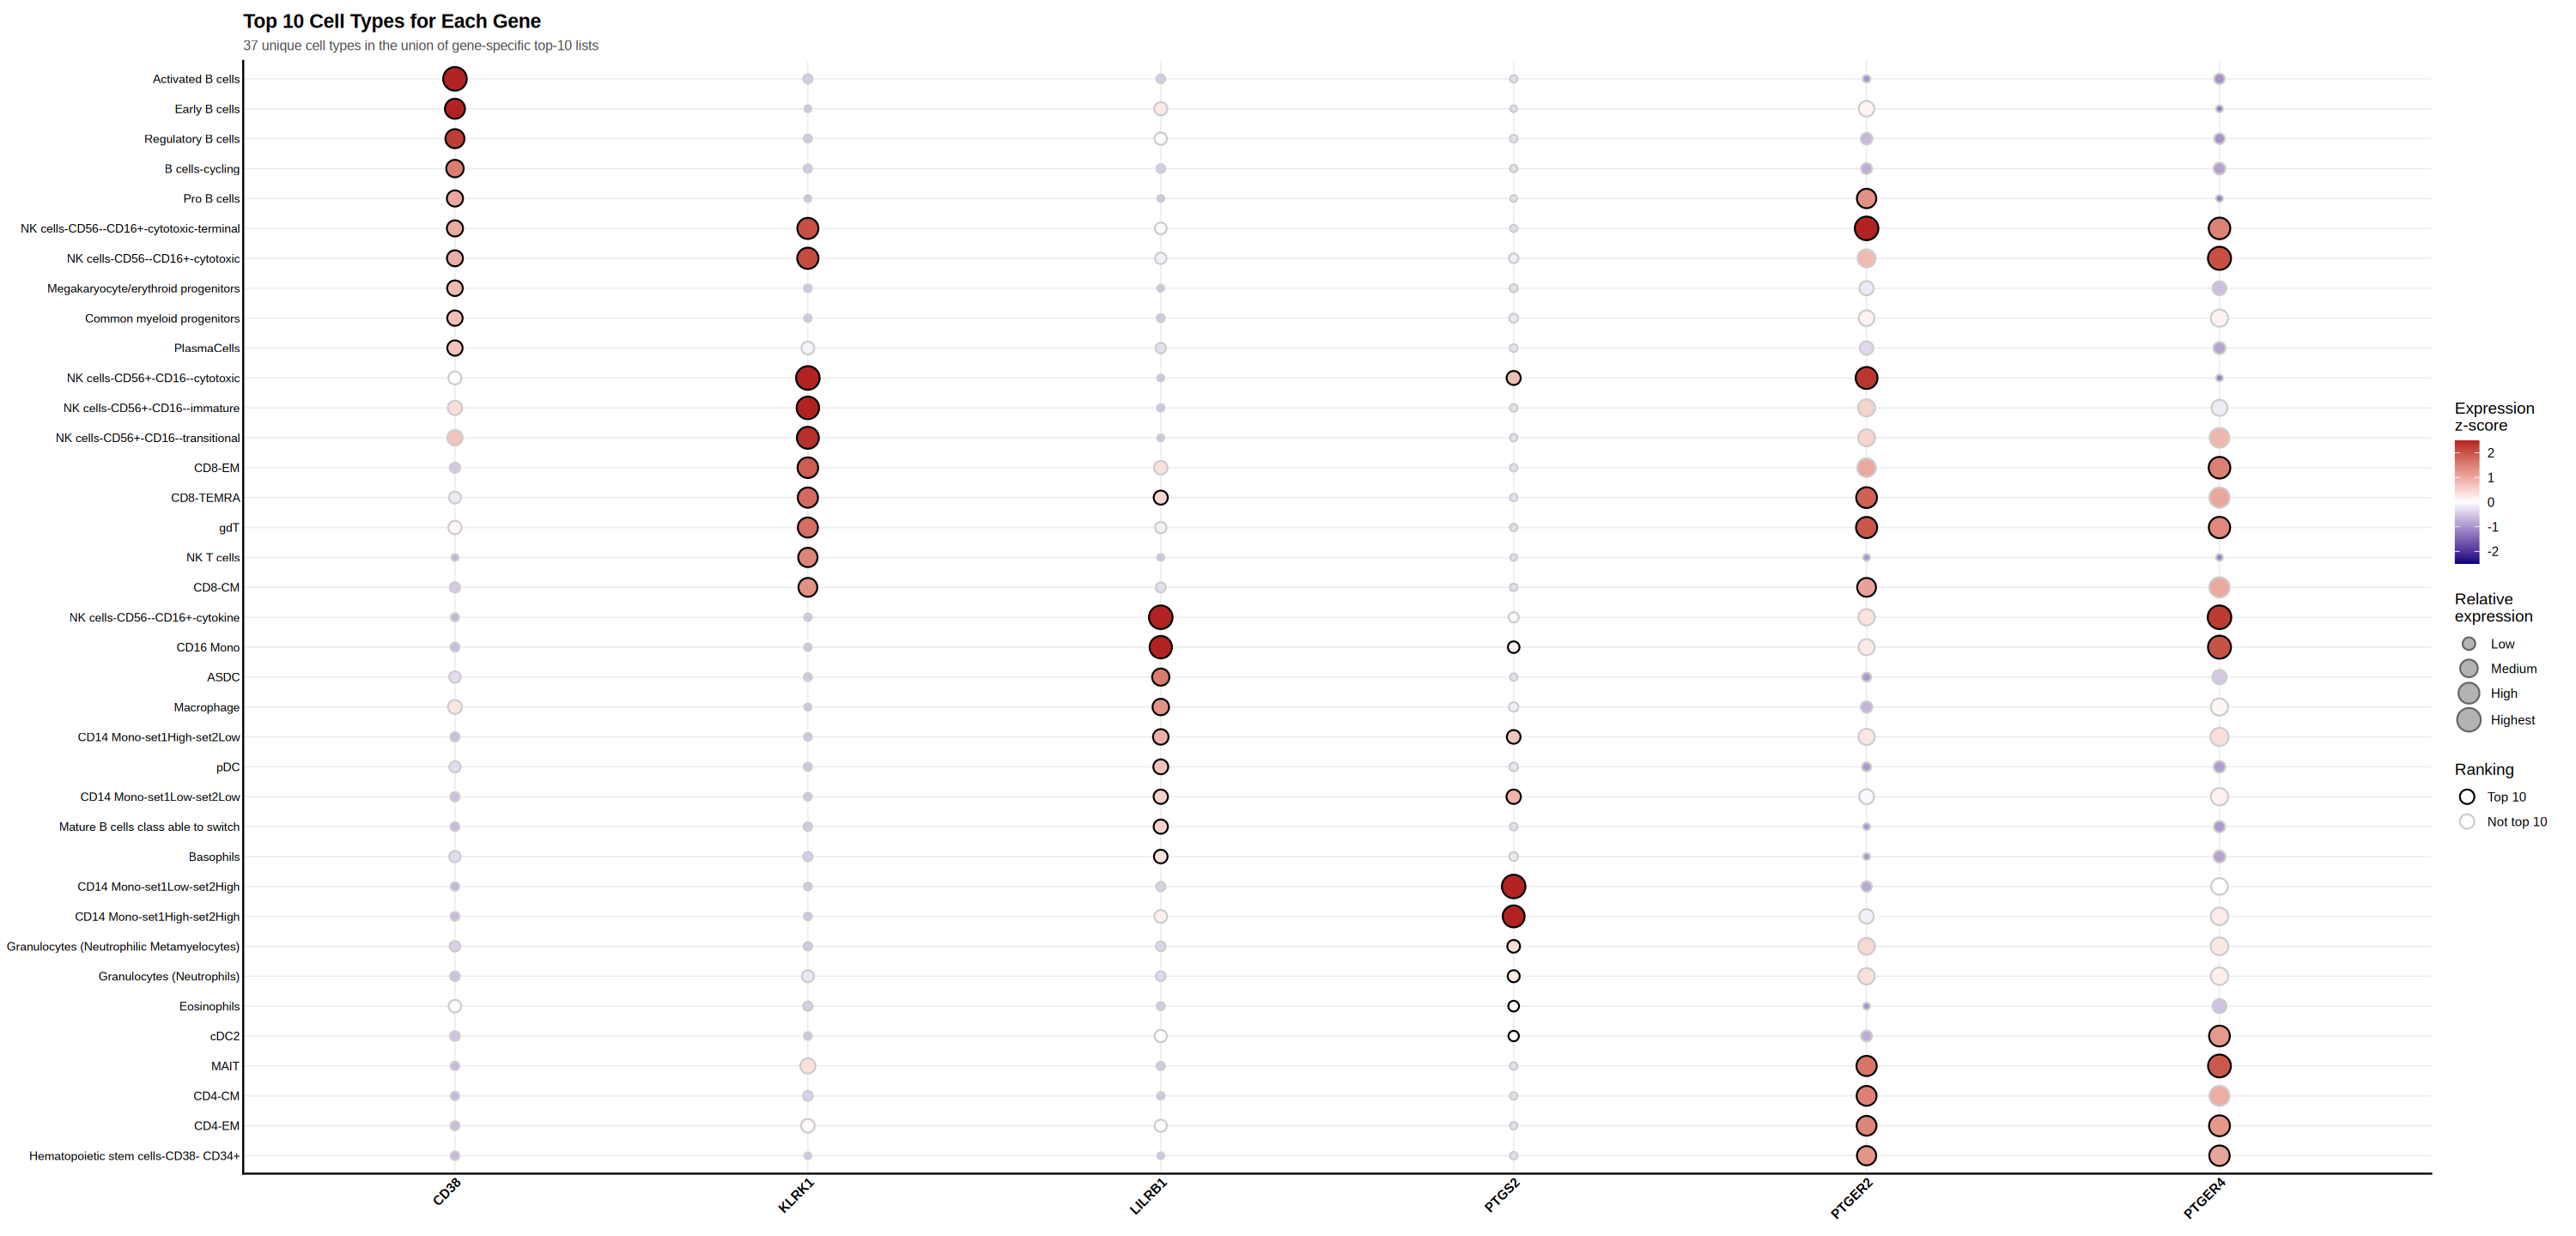

In [11]:
suppressPackageStartupMessages({
  library(Seurat)
  library(dplyr)
  library(tibble)
  library(tidyr)
  library(ggplot2)
  library(scales)
})

# ============================================================
# 0) Inputs
# ============================================================
genes_use <- c(
  "CD38",
  "KLRK1",
  "LILRB1",
  "PTGS2",
  "PTGER2",
  "PTGER4"
)

# CD38 always first
genes_use <- c("CD38", setdiff(genes_use, "CD38"))

group_col <- "Nover"
top_n <- 10L

assay_use <- DefaultAssay(sce1)
slot_use <- "data"

# ============================================================
# 1) Average expression: genes × cell types
# ============================================================
avg_list <- AverageExpression(
  sce1,
  assays = assay_use,
  features = genes_use,
  group.by = group_col,
  slot = slot_use,
  verbose = FALSE
)

avg_mat <- avg_list[[assay_use]]

# Preserve requested gene order
genes_present <- genes_use[genes_use %in% rownames(avg_mat)]

avg_mat <- avg_mat[
  genes_present,
  ,
  drop = FALSE
]

missing_genes <- setdiff(genes_use, rownames(avg_mat))

if (length(missing_genes) > 0) {
  warning(
    "Missing genes: ",
    paste(missing_genes, collapse = ", ")
  )
}

if (!"CD38" %in% rownames(avg_mat)) {
  stop("CD38 is not present in the averaged-expression matrix.")
}

# ============================================================
# 2) Long-format table containing all cell types
# ============================================================
expr_all <- as.data.frame(
  avg_mat,
  check.names = FALSE
) %>%
  tibble::rownames_to_column("gene") %>%
  tidyr::pivot_longer(
    cols = -gene,
    names_to = "cell_type",
    values_to = "mean_expr"
  ) %>%
  dplyr::mutate(
    gene = as.character(gene),
    cell_type = as.character(cell_type),
    mean_expr = as.numeric(mean_expr)
  )

# ============================================================
# 3) Calculate top 10 independently for each gene
# ============================================================
top_tbl <- expr_all %>%
  dplyr::group_by(gene) %>%
  dplyr::arrange(
    dplyr::desc(mean_expr),
    cell_type,
    .by_group = TRUE
  ) %>%
  dplyr::slice_head(n = top_n) %>%
  dplyr::mutate(
    rank_in_gene = dplyr::row_number()
  ) %>%
  dplyr::ungroup()

# Confirm exactly 10 per gene
top_counts <- top_tbl %>%
  dplyr::count(gene, name = "n_selected")

print(top_counts)

if (!all(top_counts$n_selected == top_n)) {
  stop("At least one gene does not have exactly 10 selected cell types.")
}

# Union of all top-10 cell types
selected_celltypes <- unique(top_tbl$cell_type)

message(
  "Top ", top_n,
  " from ", length(genes_present),
  " genes produced ",
  length(selected_celltypes),
  " unique cell types."
)

# ============================================================
# 4) Calculate gene-specific standardized expression
#
# z_expr:
#   expression standardized across all cell types for each gene
#
# relative_expr:
#   0–1 expression range within each gene, used for dot size
# ============================================================
expr_scaled <- expr_all %>%
  dplyr::group_by(gene) %>%
  dplyr::mutate(
    z_expr = as.numeric(scale(mean_expr)),
    relative_expr = scales::rescale(
      mean_expr,
      to = c(0.15, 1)
    )
  ) %>%
  dplyr::ungroup() %>%
  dplyr::mutate(
    z_expr = dplyr::if_else(
      is.finite(z_expr),
      z_expr,
      0
    )
  )

# Add top-10 status and rank
plot_df <- expr_scaled %>%
  dplyr::filter(cell_type %in% selected_celltypes) %>%
  dplyr::left_join(
    top_tbl %>%
      dplyr::select(
        gene,
        cell_type,
        rank_in_gene
      ) %>%
      dplyr::mutate(is_top10 = TRUE),
    by = c("gene", "cell_type")
  ) %>%
  dplyr::mutate(
    is_top10 = tidyr::replace_na(is_top10, FALSE),
    outline = ifelse(is_top10, "Top 10", "Not top 10")
  )

# ============================================================
# 5) Order cell types
#
# Cell types are ordered by:
#   1. first gene block in which they enter the top 10
#   2. best rank within that gene
# ============================================================
gene_order <- genes_present

celltype_order <- top_tbl %>%
  dplyr::mutate(
    gene_index = match(gene, gene_order)
  ) %>%
  dplyr::group_by(cell_type) %>%
  dplyr::summarise(
    first_gene_index = min(gene_index),
    best_rank = min(
      rank_in_gene[gene_index == first_gene_index],
      na.rm = TRUE
    ),
    .groups = "drop"
  ) %>%
  dplyr::arrange(
    first_gene_index,
    best_rank,
    cell_type
  ) %>%
  dplyr::pull(cell_type)

# Reverse so the first item appears at the top
plot_df <- plot_df %>%
  dplyr::mutate(
    gene = factor(gene, levels = gene_order),
    cell_type = factor(
      cell_type,
      levels = rev(celltype_order)
    ),
    outline = factor(
      outline,
      levels = c("Top 10", "Not top 10")
    )
  )

# ============================================================
# 6) Bubble heatmaps
# ============================================================

# Cap extreme z-scores for a more balanced color scale
plot_df <- plot_df %>%
  dplyr::mutate(
    z_expr_plot = pmax(
      pmin(z_expr, 2.5),
      -2.5
    )
  )

# ------------------------------------------------------------
# 6A) Horizontal plot
#     x = cell type
#     y = gene
# ------------------------------------------------------------
p_horizontal <- ggplot(
  plot_df,
  aes(
    x = cell_type,
    y = gene
  )
) +
  geom_point(
    aes(
      size = relative_expr,
      fill = z_expr_plot,
      color = outline
    ),
    shape = 21,
    stroke = 0.7
  ) +
  scale_fill_gradient2(
    low = "navy",
    mid = "white",
    high = "firebrick",
    midpoint = 0,
    limits = c(-2.5, 2.5),
    oob = scales::squish,
    name = "Expression\nz-score"
  ) +
  scale_color_manual(
    values = c(
      "Top 10" = "black",
      "Not top 10" = "grey80"
    ),
    name = NULL
  ) +
  scale_size_continuous(
    range = c(1.5, 7),
    breaks = c(0.25, 0.50, 0.75, 1.00),
    labels = c("Low", "Medium", "High", "Highest"),
    name = "Relative\nexpression"
  ) +
  labs(
    x = NULL,
    y = NULL,
    title = paste0(
      "Top ", top_n,
      " Cell Types for Each Gene"
    ),
    subtitle = paste0(
      length(selected_celltypes),
      " unique cell types in the union of gene-specific top-",
      top_n,
      " lists"
    )
  ) +
  guides(
    fill = guide_colorbar(
      order = 1,
      title.position = "top"
    ),
    size = guide_legend(
      order = 2,
      title.position = "top",
      override.aes = list(
        fill = "grey70",
        color = "grey40"
      )
    ),
    color = guide_legend(
      order = 3,
      title = "Ranking",
      title.position = "top",
      override.aes = list(
        size = 4,
        fill = "white"
      )
    )
  ) +
  theme_classic(base_size = 11) +
  theme(
    axis.text.x = element_text(
      angle = 60,
      hjust = 1,
      vjust = 1,
      size = 8
    ),
    axis.text.y = element_text(
      face = "bold",
      size = 10
    ),
    axis.ticks = element_blank(),
    panel.grid.major = element_line(
      color = "grey92",
      linewidth = 0.3
    ),
    panel.grid.minor = element_blank(),
    plot.title = element_text(
      face = "bold",
      hjust = 0
    ),
    plot.subtitle = element_text(
      size = 9,
      color = "grey30"
    ),
    legend.position = "right",
    legend.box = "vertical",
    legend.spacing.y = unit(0.3, "cm"),
    plot.margin = margin(
      t = 10,
      r = 15,
      b = 10,
      l = 10
    )
  )

# ------------------------------------------------------------
# 6B) Vertical plot
#     x = gene
#     y = cell type
# ------------------------------------------------------------
p_vertical <- ggplot(
  plot_df,
  aes(
    x = gene,
    y = cell_type
  )
) +
  geom_point(
    aes(
      size = relative_expr,
      fill = z_expr_plot,
      color = outline
    ),
    shape = 21,
    stroke = 0.7
  ) +
  scale_fill_gradient2(
    low = "navy",
    mid = "white",
    high = "firebrick",
    midpoint = 0,
    limits = c(-2.5, 2.5),
    oob = scales::squish,
    name = "Expression\nz-score"
  ) +
  scale_color_manual(
    values = c(
      "Top 10" = "black",
      "Not top 10" = "grey80"
    ),
    name = NULL
  ) +
  scale_size_continuous(
    range = c(1.5, 7),
    breaks = c(0.25, 0.50, 0.75, 1.00),
    labels = c("Low", "Medium", "High", "Highest"),
    name = "Relative\nexpression"
  ) +
  labs(
    x = NULL,
    y = NULL,
    title = paste0(
      "Top ", top_n,
      " Cell Types for Each Gene"
    ),
    subtitle = paste0(
      length(selected_celltypes),
      " unique cell types in the union of gene-specific top-",
      top_n,
      " lists"
    )
  ) +
  guides(
    fill = guide_colorbar(
      order = 1,
      title.position = "top"
    ),
    size = guide_legend(
      order = 2,
      title.position = "top",
      override.aes = list(
        fill = "grey70",
        color = "grey40"
      )
    ),
    color = guide_legend(
      order = 3,
      title = "Ranking",
      title.position = "top",
      override.aes = list(
        size = 4,
        fill = "white"
      )
    )
  ) +
  theme_classic(base_size = 11) +
  theme(
    axis.text.x = element_text(
      angle = 45,
      hjust = 1,
      face = "bold"
    ),
    axis.text.y = element_text(
      size = 8
    ),
    axis.ticks = element_blank(),
    panel.grid.major = element_line(
      color = "grey92",
      linewidth = 0.3
    ),
    panel.grid.minor = element_blank(),
    plot.title = element_text(
      face = "bold",
      hjust = 0
    ),
    plot.subtitle = element_text(
      size = 9,
      color = "grey30"
    ),
    legend.position = "right",
    legend.box = "vertical",
    legend.spacing.y = unit(0.3, "cm"),
    plot.margin = margin(
      t = 10,
      r = 15,
      b = 10,
      l = 10
    )
  )

# Display plots
print(p_horizontal)
print(p_vertical)

# ============================================================
# 7) Save figures and tables
# ============================================================

plot_width_horizontal <- max(
  12,
  length(selected_celltypes) * 0.38 + 3
)

plot_height_vertical <- max(
  7,
  length(selected_celltypes) * 0.28 + 2
)

ggsave(
  filename = "Top10_celltypes_per_gene_bubble_heatmap_horizontal.pdf",
  plot = p_horizontal,
  width = plot_width_horizontal,
  height = 5.5,
  limitsize = FALSE
)

ggsave(
  filename = "Top10_celltypes_per_gene_bubble_heatmap_horizontal.png",
  plot = p_horizontal,
  width = plot_width_horizontal,
  height = 5.5,
  dpi = 400,
  limitsize = FALSE
)

ggsave(
  filename = "Top10_celltypes_per_gene_bubble_heatmap_vertical.pdf",
  plot = p_vertical,
  width = 8.5,
  height = plot_height_vertical,
  limitsize = FALSE
)

ggsave(
  filename = "Top10_celltypes_per_gene_bubble_heatmap_vertical.png",
  plot = p_vertical,
  width = 8.5,
  height = plot_height_vertical,
  dpi = 400,
  limitsize = FALSE
)

write.csv(
  top_tbl,
  "Top10_celltypes_per_gene.csv",
  row.names = FALSE
)

write.csv(
  plot_df,
  "Top10_union_celltypes_all_gene_expression.csv",
  row.names = FALSE
)

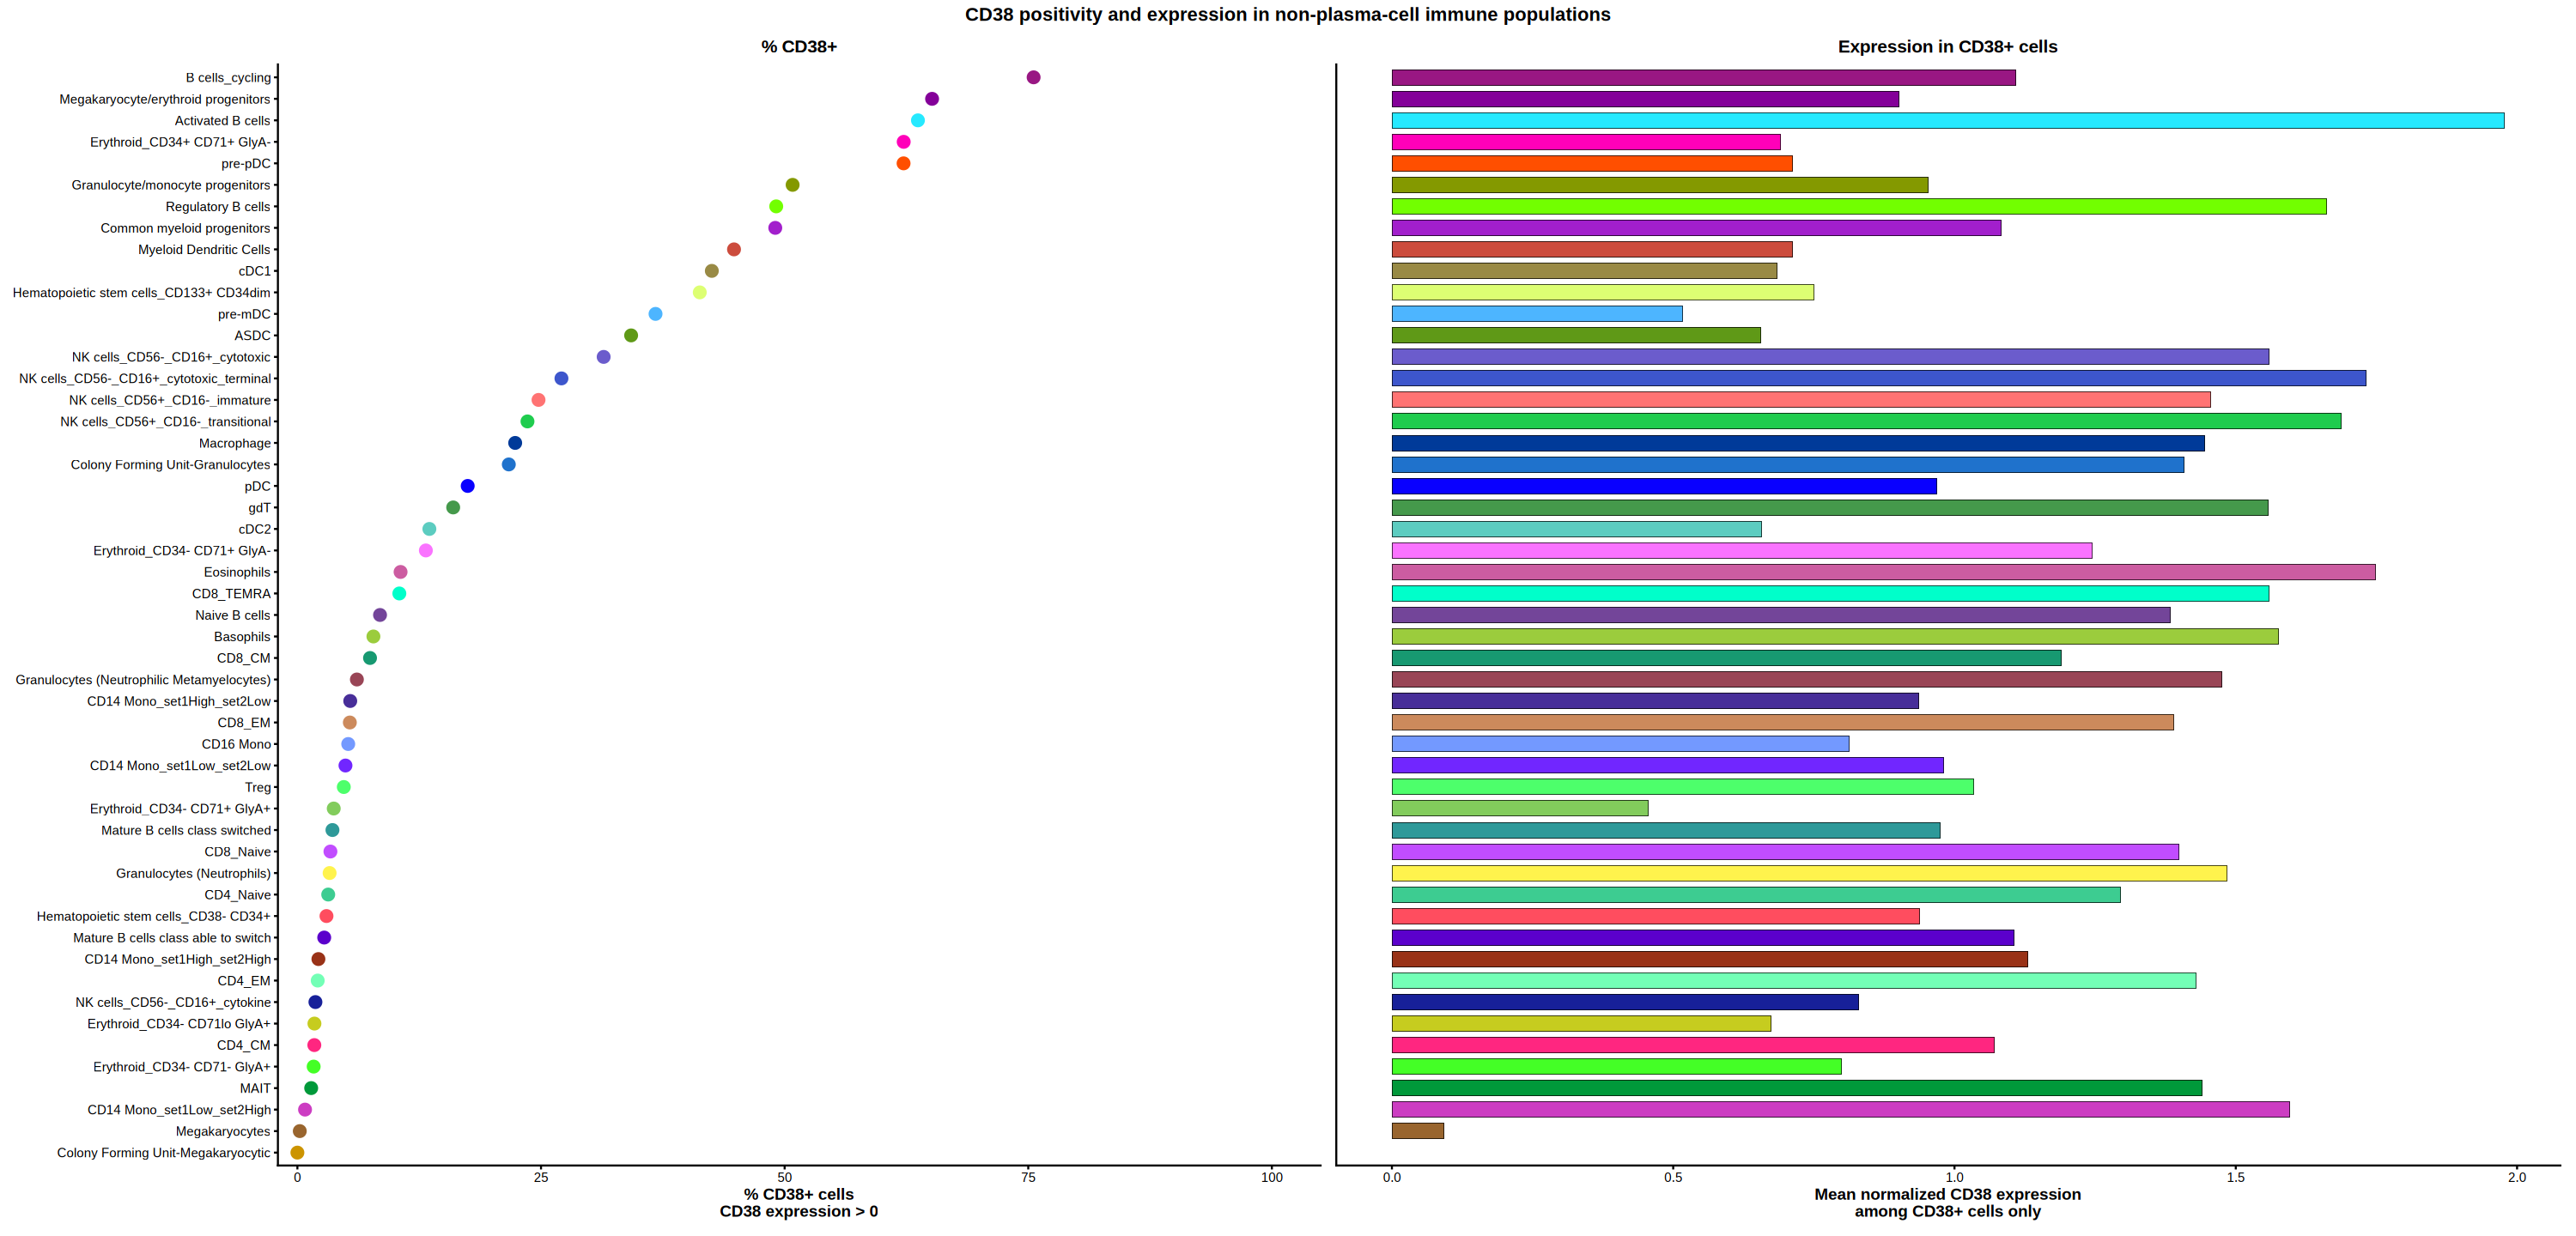

In [15]:
# ============================================================
# CD38 expression in non-plasma-cell immune populations
# Combined horizontal plot:
# left  = % CD38+ cells, ordered high to low
# right = mean normalized CD38 expression among CD38+ cells only
# ============================================================

suppressPackageStartupMessages({
  library(Seurat)
  library(dplyr)
  library(tidyr)
  library(tibble)
  library(ggplot2)
  library(ggpubr)
  library(readr)
  library(stringr)
  library(scCustomize)
  library(patchwork)
})

# -----------------------------
# 0) Configuration
# -----------------------------
gene_use <- "CD38"
celltype_col <- "Nover"       # change to "Annotation" if needed
sample_col <- "orig.ident"    # only used for n_samples filter

# User-decided cutoff for defining CD38+ cells.
# For Seurat log-normalized "data", 0 means detectable expression.
# Change to 0.1, 0.25, 0.5, etc. for stricter positivity.
cd38_positive_cutoff <- 0

min_cells <- 20
min_samples <- 2

outdir <- "CD38_nonPC_combined_plot"
dir.create(outdir, showWarnings = FALSE, recursive = TRUE)

stopifnot(gene_use %in% rownames(obj))
stopifnot(celltype_col %in% colnames(obj@meta.data))
stopifnot(sample_col %in% colnames(obj@meta.data))

# -----------------------------
# 1) Cell-type colors matched to UMAP legend
# -----------------------------
celltype_pal <- make_celltype_palette_from_umap(
  obj = obj,
  celltype_col = celltype_col,
  reduction_use = "UMAP",
  pt.size = 0.4
)

write_csv(
  tibble(
    cell_type = names(celltype_pal),
    color = unname(celltype_pal)
  ),
  file.path(outdir, "UMAP_matched_celltype_palette.csv")
)

# -----------------------------
# 2) Fetch CD38 expression and metadata
# -----------------------------
cd38_df <- FetchData(
  obj,
  vars = c(gene_use, celltype_col, sample_col),
  layer = "data"
) %>%
  rownames_to_column("cell") %>%
  rename(
    CD38_expr = all_of(gene_use),
    cell_type = all_of(celltype_col),
    sample_id = all_of(sample_col)
  ) %>%
  mutate(
    cell_type = as.character(cell_type),
    sample_id = as.character(sample_id)
  )

# -----------------------------
# 3) Remove plasma-cell populations
# -----------------------------
nonpc_cd38 <- cd38_df %>%
  filter(
    !is.na(cell_type),
    !str_detect(
      cell_type,
      regex("plasma|plasmablast|\\bPC\\b|amyloid|clone|malignant", ignore_case = TRUE)
    )
  )

write_csv(
  nonpc_cd38,
  file.path(outdir, "CD38_nonPC_cell_level_table.csv.gz")
)

# -----------------------------
# 4) Summarize CD38 positivity and expression
# -----------------------------
cd38_rank <- nonpc_cd38 %>%
  mutate(
    CD38_positive = CD38_expr > cd38_positive_cutoff
  ) %>%
  group_by(cell_type) %>%
  summarise(
    n_cells = n(),
    n_samples = n_distinct(sample_id),
    n_CD38_positive = sum(CD38_positive, na.rm = TRUE),
    pct_CD38_positive = mean(CD38_positive, na.rm = TRUE) * 100,

    # Mean expression among CD38+ cells only
    mean_CD38_positive_cells = ifelse(
      n_CD38_positive > 0,
      mean(CD38_expr[CD38_positive], na.rm = TRUE),
      NA_real_
    ),

    median_CD38_positive_cells = ifelse(
      n_CD38_positive > 0,
      median(CD38_expr[CD38_positive], na.rm = TRUE),
      NA_real_
    ),

    .groups = "drop"
  ) %>%
  filter(
    n_cells >= min_cells,
    n_samples >= min_samples
  ) %>%
  arrange(desc(pct_CD38_positive)) %>%
  mutate(
    # Highest % CD38+ appears on top
    cell_type = factor(cell_type, levels = rev(unique(cell_type)))
  )

cutoff_tag <- str_replace_all(as.character(cd38_positive_cutoff), "\\.", "p")

write_csv(
  cd38_rank,
  file.path(outdir, paste0(
    "CD38_nonPC_summary_ordered_by_pct_positive_cutoff_",
    cutoff_tag,
    ".csv"
  ))
)

# Add fallback colors if some plotted cell types are missing from UMAP palette
missing_ct <- setdiff(as.character(cd38_rank$cell_type), names(celltype_pal))

if (length(missing_ct) > 0) {
  fallback_cols <- grDevices::hcl.colors(length(missing_ct), palette = "Dark 3")
  names(fallback_cols) <- missing_ct
  celltype_pal <- c(celltype_pal, fallback_cols)
}

# -----------------------------
# 5) Left panel: % CD38+ cells
# -----------------------------
p_pct_dot <- ggplot(
  cd38_rank,
  aes(
    y = cell_type,
    x = pct_CD38_positive,
    color = cell_type
  )
) +
  geom_point(size = 3.5) +
  scale_color_manual(values = celltype_pal, guide = "none") +
  scale_x_continuous(
    limits = c(0, 100),
    breaks = c(0, 25, 50, 75, 100),
    expand = expansion(mult = c(0.02, 0.05))
  ) +
  theme_pub(base_size = 11) +
  theme(
    axis.title.y = element_blank(),
    plot.title = element_text(hjust = 0.5),
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank()
  ) +
  labs(
    x = paste0("% CD38+ cells\nCD38 expression > ", cd38_positive_cutoff),
    title = "% CD38+"
  )

# -----------------------------
# 6) Right panel: mean CD38 expression among CD38+ cells only
# -----------------------------
p_mean_pos_bar <- ggplot(
  cd38_rank,
  aes(
    y = cell_type,
    x = mean_CD38_positive_cells,
    fill = cell_type
  )
) +
  geom_col(
    width = 0.72,
    color = "black",
    linewidth = 0.15,
    na.rm = TRUE
  ) +
  scale_fill_manual(values = celltype_pal, guide = "none") +
  theme_pub(base_size = 11) +
  theme(
    axis.title.y = element_blank(),
    axis.text.y = element_blank(),
    axis.ticks.y = element_blank(),
    plot.title = element_text(hjust = 0.5),
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank()
  ) +
  labs(
    x = "Mean normalized CD38 expression\namong CD38+ cells only",
    title = "Expression in CD38+ cells"
  )

# -----------------------------
# 7) Combined plot
# -----------------------------
p_cd38_combined <- p_pct_dot + p_mean_pos_bar +
  plot_layout(widths = c(1.15, 1.35)) +
  plot_annotation(
    title = "CD38 positivity and expression in non-plasma-cell immune populations",
    theme = theme(
      plot.title = element_text(
        hjust = 0.5,
        face = "bold",
        size = 13
      )
    )
  )

print(p_cd38_combined)

# -----------------------------
# 8) Save figure
# -----------------------------
fig_height <- max(3.8, 0.28 * nrow(cd38_rank))

ggsave(
  file.path(outdir, paste0(
    "CD38_nonPC_pct_positive_left_mean_positive_expr_right_cutoff_",
    cutoff_tag,
    ".pdf"
  )),
  p_cd38_combined,
  width = 9.5,
  height = fig_height,
  useDingbats = FALSE
)

ggsave(
  file.path(outdir, paste0(
    "CD38_nonPC_pct_positive_left_mean_positive_expr_right_cutoff_",
    cutoff_tag,
    ".png"
  )),
  p_cd38_combined,
  width = 9.5,
  height = fig_height,
  dpi = 600
)